# Modelos predictores de Implied Volatility







El **objetivo** de este notebook es aplicar diversos modelos y técnicas de IA y RRNN para encontrar el mejor modelo capaz de hacer una predicción con el mínimo error de la Volatilidad Implícita de trades de opciones del IBEX 35.

In [1]:
from tqdm import tqdm

from pathlib import Path
import json
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_management.loaders import VolatilityStepLoader
from src.enums.data_enums.database_schema.volatility_db_enum import VolatilityDBEnum
from src.enums.data_enums.option_type_enum import OptionTypeEnum

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Selección de variables y Feature Engineering

In [2]:
volatility_df = VolatilityStepLoader.read_step_databases().copy()

# Columnas escogidas para features + target + auditoría
selected_cols = [
    VolatilityDBEnum.EXEC_DATETIME,
    VolatilityDBEnum.OPTION_CONTRACT_CODE,
    VolatilityDBEnum.OPTION_TYPE,
    VolatilityDBEnum.QUANTITY,
    VolatilityDBEnum.STRIKE_PRICE,
    VolatilityDBEnum.TRADE_TYPE,
    VolatilityDBEnum.UNDERLYING_LAG_MINUTES,
    VolatilityDBEnum.UNDERLYING_PRICE,
    VolatilityDBEnum.TIME_TO_EXPIRATION,
    VolatilityDBEnum.RATE,
    VolatilityDBEnum.IMPLIED_VOLATILITY,
]

volatility_df = volatility_df[selected_cols].copy()
print("Rows loaded:", len(volatility_df))
display(volatility_df.head())

Rows loaded: 314877


,ExecDatetime,OptionContractCode,OptionType,Quantity,StrikePrice,TradeType,UnderlyingLagMinutes,UnderlyingPrice,TimeToExpiration,Rate,ImpliedVolatility
0,2017-01-02 09:13:43,CIBX 9600F17,C,3,9600.0,M,0.433333,9305.0,18.344641,-0.494698,0.175114
1,2017-01-02 09:23:09,PIBX 8200F17,P,5000,8200.0,H,0.1,9314.0,18.338091,-0.494875,0.265431
2,2017-01-02 09:24:08,CIBX 9300F17,C,1,9300.0,M,0.816667,9314.0,18.337408,-0.494893,0.189698
3,2017-01-02 09:29:21,PIBX 8500F17,P,5000,8500.0,H,0.333333,9322.0,18.333784,-0.494991,0.243136
4,2017-01-02 09:32:52,CIBX 9400F17,C,1,9400.0,M,0.0,9331.0,18.331343,-0.495057,0.185167


Adicionalmente, hay que crear un catálogo de las variables categóricas porque hay que aplicarle one-hot encoding.

In [3]:
# Catálogo de trade_type
TRADE_TYPE_CATALOG = {
    "M": "Descripción M",
    "H": "Descripción H",
    "X": "Descripción X",
    "W": "Descripción W",
    "3": "Descripción 3",
}

# Catálogo de exec_hour
EXEC_HOUR_CATALOG = {
    9: "9:00 - 9:59",
    10: "10:00 - 10:59",
    11: "11:00 - 11:59",
    12: "12:00 - 12:59",
    13: "13:00 - 13:59",
    14: "14:00 - 14:59",
    15: "15:00 - 15:59",
    16: "16:00 - 16:59",
    17: "17:00 - 17:59",
    18: "18:00 - 18:59",
    19: "19:00 - 19:59"
}

# Catálogo de exec_weekday
EXEC_WEEKDAY_CATALOG = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday"
}

In [4]:
### Feature engineering ###

# Definición de columnas base para features numéricas y categóricas
BASE_NUMERIC_FEATURE_COLS = [
    "tte_years",
    "sqrt_tte_years",
    "log_moneyness",
    "log_moneyness_sq",
    "log_moneyness_x_sqrt_tte",
    "log_forward_moneyness",
    "rate",
    "underlying_lag_minutes",
    "quantity_log1p",
]

# Mapeo columnas one-hot
TRADE_TYPE_TO_FEATURE = {tid: f"trade_type_{tid}" for tid in TRADE_TYPE_CATALOG.keys()}
TRADE_TYPE_FEATURE_COLS = list(TRADE_TYPE_TO_FEATURE.values())
EXEC_HOUR_TO_FEATURE = {hour: f"exec_hour_{hour}" for hour in EXEC_HOUR_CATALOG.keys()}
EXEC_HOUR_FEATURE_COLS = list(EXEC_HOUR_TO_FEATURE.values())
EXEC_WEEKDAY_TO_FEATURE = {weekday: f"exec_weekday_{weekday}" for weekday in EXEC_WEEKDAY_CATALOG.keys()}
EXEC_WEEKDAY_FEATURE_COLS = list(EXEC_WEEKDAY_TO_FEATURE.values())

BASE_CATEGORICAL_FEATURE_COLS = [
    "is_call",
    *TRADE_TYPE_FEATURE_COLS,
    *EXEC_HOUR_FEATURE_COLS,
    *EXEC_WEEKDAY_FEATURE_COLS,
]

BASE_FEATURE_COLS = BASE_NUMERIC_FEATURE_COLS + BASE_CATEGORICAL_FEATURE_COLS
TARGET_COL = VolatilityDBEnum.IMPLIED_VOLATILITY

# Columnas auxiliares para análisis posterior (no entran al modelo)
AUX_CONTEXT_COLS = [
    VolatilityDBEnum.EXEC_DATETIME,
    VolatilityDBEnum.OPTION_CONTRACT_CODE,
]

# Construcción de features por fila (útil para explicabilidad posterior)
def build_features_from_trade(tr) -> dict:
    """
    Construye el diccionario de features por trade.
    """

    tte_years = tr[VolatilityDBEnum.TIME_TO_EXPIRATION] / 365.0
    sqrt_tte_years = np.sqrt(tte_years)

    underlying_price = tr[VolatilityDBEnum.UNDERLYING_PRICE]
    strike_price = tr[VolatilityDBEnum.STRIKE_PRICE]
    log_moneyness = np.log(underlying_price / strike_price)
    log_moneyness_sq = log_moneyness ** 2
    log_moneyness_x_sqrt_tte = log_moneyness * sqrt_tte_years

    rate = tr[VolatilityDBEnum.RATE]
    forward_price = underlying_price * np.exp(rate * tte_years)
    log_forward_moneyness = np.log(forward_price / strike_price)

    is_call = float(str(tr[VolatilityDBEnum.OPTION_TYPE]).upper() == OptionTypeEnum.CALL)

    exec_dt = tr[VolatilityDBEnum.EXEC_DATETIME]
    exec_hour = int(exec_dt.hour)
    exec_weekday = int(exec_dt.weekday())

    quantity_raw = tr[VolatilityDBEnum.QUANTITY]
    quantity_log1p = np.log1p(quantity_raw)

    underlying_lag_minutes = tr[VolatilityDBEnum.UNDERLYING_LAG_MINUTES]

    features = {
        "tte_years": tte_years,
        "sqrt_tte_years": sqrt_tte_years,
        "log_moneyness": log_moneyness,
        "log_moneyness_sq": log_moneyness_sq,
        "log_moneyness_x_sqrt_tte": log_moneyness_x_sqrt_tte,
        "log_forward_moneyness": log_forward_moneyness,
        "rate": rate,
        "is_call": is_call,
        "underlying_lag_minutes": underlying_lag_minutes,
        "quantity_log1p": quantity_log1p,
    }

    trade_value = str(tr[VolatilityDBEnum.TRADE_TYPE])
    for tid, col_name in TRADE_TYPE_TO_FEATURE.items():
        features[col_name] = float(trade_value == tid)

    for hour, col_name in EXEC_HOUR_TO_FEATURE.items():
        features[col_name] = float(exec_hour == hour)

    for weekday, col_name in EXEC_WEEKDAY_TO_FEATURE.items():
        features[col_name] = float(exec_weekday == weekday)

    return features

# Construcción de features sobre el dataset
feature_df = volatility_df.copy()

# Verificaciones auxiliares
feature_df = feature_df[
    feature_df[VolatilityDBEnum.EXEC_DATETIME].notna()
    & (feature_df[VolatilityDBEnum.UNDERLYING_PRICE] > 0)
    & (feature_df[VolatilityDBEnum.STRIKE_PRICE] > 0)
    & (feature_df[VolatilityDBEnum.TIME_TO_EXPIRATION] > 0)
    & (feature_df[VolatilityDBEnum.RATE].notna())
    & (feature_df[VolatilityDBEnum.QUANTITY].fillna(0) >= 0)
    & feature_df[VolatilityDBEnum.TRADE_TYPE].astype(str).isin(TRADE_TYPE_CATALOG.keys())
    & feature_df[VolatilityDBEnum.EXEC_DATETIME].dt.hour.isin(EXEC_HOUR_CATALOG.keys())
    & feature_df[VolatilityDBEnum.EXEC_DATETIME].dt.weekday.isin(EXEC_WEEKDAY_CATALOG.keys())
] .copy()

feature_df = feature_df.sort_values(VolatilityDBEnum.EXEC_DATETIME).reset_index(drop=True)
new_features = feature_df.apply(
    lambda row: pd.Series(build_features_from_trade(row)),
    axis=1
)
model_df = pd.concat([feature_df, new_features], axis=1)

# Seleccionamos columnas finales
model_df = model_df[BASE_FEATURE_COLS + [TARGET_COL] + AUX_CONTEXT_COLS].copy()

print(f"Rows after feature engineering: {len(model_df)}")

Rows after feature engineering: 314862


In [5]:
feature_inventory = pd.DataFrame(
    {
        "block": ["numeric", "categorical", "target", "aux_context"],
        "n_columns": [
            len(BASE_NUMERIC_FEATURE_COLS),
            len(BASE_CATEGORICAL_FEATURE_COLS),
            1,
            len(AUX_CONTEXT_COLS),
        ],
    }
)

print("Resumen de columnas del dataset:")
display(feature_inventory)

print("\nResumen de features:")
print(f"  - Numéricas ({len(BASE_NUMERIC_FEATURE_COLS)}): {BASE_NUMERIC_FEATURE_COLS}")
print(f"  - Categóricas ({len(BASE_CATEGORICAL_FEATURE_COLS)}): {BASE_CATEGORICAL_FEATURE_COLS}")
print(f"  - Total features modelo: {len(BASE_FEATURE_COLS)}")
print("\nColumnas auxiliares NO usadas para entrenar:", AUX_CONTEXT_COLS)

print("\n" + "="*60)
print("FEATURE STATISTICS (numéricas):")
print("="*60)
display(model_df[BASE_NUMERIC_FEATURE_COLS].describe())

print("\n" + "="*60)
print("FEATURE DISTRIBUTION (categóricas):")
print("="*60)

categorical_summary_groups = {
    "is_call": ["is_call"],
    "trade_type": TRADE_TYPE_FEATURE_COLS,
    "exec_hour": EXEC_HOUR_FEATURE_COLS,
    "exec_weekday": EXEC_WEEKDAY_FEATURE_COLS,
}

for group_name, group_cols in categorical_summary_groups.items():
    print(f"\n{group_name}:")
    if len(group_cols) == 1:
        display(model_df[group_cols[0]].value_counts().sort_index())
    else:
        group_counts = model_df[group_cols].sum().sort_values(ascending=False).astype(int)
        display(group_counts.to_frame(name="count"))

print("\n" + "="*60)
print("TARGET VARIABLE (Implied Volatility):")
print("="*60)
display(model_df[[TARGET_COL]].describe())

print("\n" + "="*60)
print("DATA QUALITY:")
print("="*60)
print(f"Total rows: {len(model_df)}")
print(f"Date range: {model_df[VolatilityDBEnum.EXEC_DATETIME].min()} to {model_df[VolatilityDBEnum.EXEC_DATETIME].max()}")
missing_counts = model_df[BASE_FEATURE_COLS + [TARGET_COL]].isna().sum()
if missing_counts.sum() > 0:
    print("\nMissing values in features/target:")
    print(missing_counts[missing_counts > 0])
else:
    print("No missing values in features/target")

print("\nCorrelation with target (top 8):")
correlations = model_df[BASE_FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
display(correlations.head(8))

Resumen de columnas del dataset:


Resumen de columnas del dataset:


,block,n_columns
0,numeric,9
1,categorical,22
2,target,1
3,aux_context,2


Resumen de columnas del dataset:


,block,n_columns
0,numeric,9
1,categorical,22
2,target,1
3,aux_context,2


...

,count
exec_weekday_4,72800
exec_weekday_3,65129
exec_weekday_2,59300
exec_weekday_0,59233
exec_weekday_1,58400



TARGET VARIABLE (Implied Volatility):


,ImpliedVolatility
count,314862.0
mean,0.206205
std,0.155218
min,0.02513
25%,0.141937
50%,0.173781
75%,0.226484
max,8.84574



DATA QUALITY:
Total rows: 314862
Date range: 2017-01-02 09:13:43 to 2022-06-28 17:30:45.051696
No missing values in features/target

Correlation with target (top 8):


log_moneyness_sq            0.352765
sqrt_tte_years              0.216419
rate                        0.163567
tte_years                   0.130209
is_call                     0.116957
log_moneyness_x_sqrt_tte    0.087100
log_moneyness               0.075653
exec_weekday_4              0.069805
Name: ImpliedVolatility, dtype: float64

## Data split temporal

Se va a realizar un split en train validation y test, pero, a su vez, como se va a trabajar con varias ramas de familias de modelos, el conjunto de train se va splitear de nuevo usando la estrategia de los CVs consecutivos con cierto lag de fechas.

In [6]:
# Primer split: Train, validation y test por fechas (70% - 15% - 15%)
exec_dates = model_df[VolatilityDBEnum.EXEC_DATETIME].dt.date
unique_dates_total = np.array(sorted(exec_dates.unique()))
n_dates_total = len(unique_dates_total)
train_end = int(n_dates_total * 0.70)
valid_end = int(n_dates_total * 0.85)

train_dates = unique_dates_total[:train_end]
valid_dates = unique_dates_total[train_end:valid_end]
test_dates = unique_dates_total[valid_end:]

train_df = model_df[exec_dates.isin(train_dates)].copy()
valid_df = model_df[exec_dates.isin(valid_dates)].copy()
test_df = model_df[exec_dates.isin(test_dates)].copy()

splits = [
    ("Train", train_df, train_dates),
    ("Valid", valid_df, valid_dates),
    ("Test", test_df, test_dates),
]

total_rows = len(model_df)
total_dates = len(unique_dates_total)

print("=" * 95)
print("SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test")
print("=" * 95)
print(f"Total filas: {total_rows:,} | Total fechas: {total_dates:,}")

for name, split_df, split_dates in splits:
    rows = len(split_df)
    dates = len(split_dates)
    start_date = split_dates[0] if dates > 0 else "N/A"
    end_date = split_dates[-1] if dates > 0 else "N/A"
    print(
        f"{name:<5} | rows: {rows:>8,} ({rows / total_rows:>7.2%}) "
        f"| dates: {dates:>5,} ({dates / total_dates:>7.2%}) "
        f"| range: {start_date} -> {end_date}"
    )

# Segundo split: k-fold por fechas para validación cruzada temporal sobre train
n_folds = 5
n_blocks = n_folds + 2  # t0..t6 => 7 bloques

date_blocks = np.array_split(train_dates, n_blocks)

folds_dates_dict = []
for i in range(n_folds):
    fold_train_dates = np.concatenate(date_blocks[: i + 2]).tolist()   # t0..t(i+1)
    fold_valid_dates = date_blocks[i + 2].tolist()                     # t(i+2)

    folds_dates_dict.append(
        (f"fold-{i+1}", {"train_dates": fold_train_dates, "valid_dates": fold_valid_dates})
    )

print("\n" + "=" * 95)
print("K-FOLDS TEMPORALES (solo dentro de Train) para validación por familia de modelos")
print("=" * 95)
print(f"Train global -> filas: {len(train_df):,} | fechas: {len(train_dates):,}")

train_exec_dates = train_df[VolatilityDBEnum.EXEC_DATETIME].dt.date

for fold_name, fold_dates in folds_dates_dict:
    fold_train_dates = fold_dates["train_dates"]
    fold_valid_dates = fold_dates["valid_dates"]

    fold_train_df = train_df[train_exec_dates.isin(fold_train_dates)]
    fold_valid_df = train_df[train_exec_dates.isin(fold_valid_dates)]

    train_rows = len(fold_train_df)
    valid_rows = len(fold_valid_df)
    train_n_dates = len(fold_train_dates)
    valid_n_dates = len(fold_valid_dates)

    train_start = fold_train_dates[0]
    train_end_date = fold_train_dates[-1]
    valid_start = fold_valid_dates[0]
    valid_end_date = fold_valid_dates[-1]

    print(f"\n{fold_name.upper()}")
    print(
        f"  TRAIN | rows: {train_rows:>8,} ({train_rows / len(train_df):>7.2%} de train) "
        f"| dates: {train_n_dates:>5,} ({train_n_dates / len(train_dates):>7.2%} de train) "
        f"| range: {train_start} -> {train_end_date}"
    )
    print(
        f"  VALID | rows: {valid_rows:>8,} ({valid_rows / len(train_df):>7.2%} de train) "
        f"| dates: {valid_n_dates:>5,} ({valid_n_dates / len(train_dates):>7.2%} de train) "
        f"| range: {valid_start} -> {valid_end_date}"
    )

SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
Total filas: 314,862 | Total fechas: 1,402
Train | rows:  244,871 ( 77.77%) | dates:   981 ( 69.97%) | range: 2017-01-02 -> 2020-11-04
Valid | rows:   32,784 ( 10.41%) | dates:   210 ( 14.98%) | range: 2020-11-05 -> 2021-08-31
Test  | rows:   37,207 ( 11.82%) | dates:   211 ( 15.05%) | range: 2021-09-01 -> 2022-06-28

K-FOLDS TEMPORALES (solo dentro de Train) para validación por familia de modelos
Train global -> filas: 244,871 | fechas: 981

FOLD-1
  TRAIN | rows:   88,003 ( 35.94% de train) | dates:   281 ( 28.64% de train) | range: 2017-01-02 -> 2018-02-07
  VALID | rows:   31,340 ( 12.80% de train) | dates:   140 ( 14.27% de train) | range: 2018-02-08 -> 2018-08-27

FOLD-2
  TRAIN | rows:  119,343 ( 48.74% de train) | dates:   421 ( 42.92% de train) | range: 2017-01-02 -> 2018-08-27
  VALID | rows:   36,417 ( 14.87% de train) | dates:   140 ( 14.27% de train) | range: 2018-08-28 -> 2019-03-14

FOLD-3
  TRAIN | row

In [ ]:
# # Primer split: Train, validation y test por fechas (70% - 15% - 15%)
# exec_dates = model_df[VolatilityDBEnum.EXEC_DATETIME].dt.date
# unique_dates_total = np.array(sorted(exec_dates.unique()))
# n_dates_total = len(unique_dates_total)
# train_end = int(n_dates_total * 0.70)
# valid_end = int(n_dates_total * 0.85)

# train_dates = unique_dates_total[:train_end]
# valid_dates = unique_dates_total[train_end:valid_end]
# test_dates = unique_dates_total[valid_end:]

# train_df = model_df[exec_dates.isin(train_dates)].copy()
# valid_df = model_df[exec_dates.isin(valid_dates)].copy()
# test_df = model_df[exec_dates.isin(test_dates)].copy()

# # Regla global por contrato: cada OPTION_CONTRACT_CODE se queda solo en un subset
# contract_col = VolatilityDBEnum.OPTION_CONTRACT_CODE
# subset_order = ["Train", "Valid", "Test"]  # desempate estable
# subset_dfs = {"Train": train_df, "Valid": valid_df, "Test": test_df}

# split_per_contract = (
#     pd.concat(
#         [
#             subset_dfs[subset_name][[contract_col]].assign(split_name=subset_name)
#             for subset_name in subset_order
#         ],
#         axis=0,
#         ignore_index=True,
#     )
#     .groupby([contract_col, "split_name"], as_index=False)
#     .size()
#     .rename(columns={"size": "n_trades"})
# )

# split_per_contract["split_rank"] = split_per_contract["split_name"].map(
#     {k: i for i, k in enumerate(subset_order)}
# )
# contract_winner = (
#     split_per_contract.sort_values(
#         by=[contract_col, "n_trades", "split_rank"],
#         ascending=[True, False, True],
#     )
#     .drop_duplicates(subset=[contract_col], keep="first")
#     [[contract_col, "split_name"]]
#     .rename(columns={"split_name": "winner_split"})
# )

# # No se mueven trades de subset: se eliminan en los subsets no ganadores
# train_df = train_df.merge(contract_winner, on=contract_col, how="left")
# train_df = train_df[train_df["winner_split"] == "Train"].drop(columns=["winner_split"]).copy()
# valid_df = valid_df.merge(contract_winner, on=contract_col, how="left")
# valid_df = valid_df[valid_df["winner_split"] == "Valid"].drop(columns=["winner_split"]).copy()
# test_df = test_df.merge(contract_winner, on=contract_col, how="left")
# test_df = test_df[test_df["winner_split"] == "Test"].drop(columns=["winner_split"]).copy()

# splits = [
#     ("Train", train_df, train_dates),
#     ("Valid", valid_df, valid_dates),
#     ("Test", test_df, test_dates),
# ]

# total_rows = len(model_df)
# total_dates = len(unique_dates_total)
# rows_after_contract_rule = len(train_df) + len(valid_df) + len(test_df)
# rows_removed_by_contract_rule = total_rows - rows_after_contract_rule

# print("=" * 95)
# print("SPLIT TEMPORAL INICIAL + REASIGNACION POR OPTION_CONTRACT_CODE")
# print("=" * 95)
# print(f"Total filas origen: {total_rows:,} | Total fechas: {total_dates:,}")
# print(
#     f"Filas tras regla de contrato: {rows_after_contract_rule:,} "
#     f"| filas eliminadas: {rows_removed_by_contract_rule:,}"
# )

# for name, split_df, split_dates in splits:
#     rows = len(split_df)
#     dates = len(split_dates)
#     start_date = split_dates[0] if dates > 0 else "N/A"
#     end_date = split_dates[-1] if dates > 0 else "N/A"
#     print(
#         f"{name:<5} | rows: {rows:>8,} ({rows / total_rows:>7.2%}) "
#         f"| dates: {dates:>5,} ({dates / total_dates:>7.2%}) "
#         f"| range: {start_date} -> {end_date}"
#     )

# contract_uniqueness = pd.concat(
#     [
#         train_df[[contract_col]].assign(split_name="Train"),
#         valid_df[[contract_col]].assign(split_name="Valid"),
#         test_df[[contract_col]].assign(split_name="Test"),
#     ],
#     axis=0,
#     ignore_index=True,
# ).groupby(contract_col)["split_name"].nunique()
# n_mixed_global = int((contract_uniqueness > 1).sum())
# print(f"Contratos mezclados entre Train/Valid/Test: {n_mixed_global}")

# # Segundo split: k-fold por fechas para validación cruzada temporal sobre train
# n_folds = 5
# n_blocks = n_folds + 2  # t0..t6 => 7 bloques

# date_blocks = np.array_split(train_dates, n_blocks)

# folds_dates_dict = []
# for i in range(n_folds):
#     fold_train_dates = np.concatenate(date_blocks[: i + 2]).tolist()   # t0..t(i+1)
#     fold_valid_dates = date_blocks[i + 2].tolist()                     # t(i+2)

#     folds_dates_dict.append(
#         (f"fold-{i+1}", {"train_dates": fold_train_dates, "valid_dates": fold_valid_dates})
#     )

# print("\n" + "=" * 95)
# print("K-FOLDS TEMPORALES (solo dentro de Train) con regla no-mezcla por contrato")
# print("=" * 95)
# print(f"Train global -> filas: {len(train_df):,} | fechas: {len(train_dates):,}")

# train_exec_dates = train_df[VolatilityDBEnum.EXEC_DATETIME].dt.date

# for fold_name, fold_dates in folds_dates_dict:
#     fold_train_dates = fold_dates["train_dates"]
#     fold_valid_dates = fold_dates["valid_dates"]

#     fold_train_df = train_df[train_exec_dates.isin(fold_train_dates)]
#     fold_valid_df = train_df[train_exec_dates.isin(fold_valid_dates)]

#     train_rows = len(fold_train_df)
#     valid_rows = len(fold_valid_df)
#     train_n_dates = len(fold_train_dates)
#     valid_n_dates = len(fold_valid_dates)

#     train_start = fold_train_dates[0]
#     train_end_date = fold_train_dates[-1]
#     valid_start = fold_valid_dates[0]
#     valid_end_date = fold_valid_dates[-1]

#     print(f"\n{fold_name.upper()}")
#     print(
#         f"  TRAIN | rows: {train_rows:>8,} ({train_rows / len(train_df):>7.2%} de train) "
#         f"| dates: {train_n_dates:>5,} ({train_n_dates / len(train_dates):>7.2%} de train) "
#         f"| range: {train_start} -> {train_end_date}"
#     )
#     print(
#         f"  VALID | rows: {valid_rows:>8,} ({valid_rows / len(train_df):>7.2%} de train) "
#         f"| dates: {valid_n_dates:>5,} ({valid_n_dates / len(train_dates):>7.2%} de train) "
#         f"| range: {valid_start} -> {valid_end_date}"
#     )

## Funciones de métricas y gráficas de resultados

In [ ]:
######## CONFIGURACIONES ########
# Configuración de selección del mejor modelo
MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1 = {
    "metric": "custom_error1",
    "mode": "min",
    "alpha": 0.25,
    "beta": 0.75,
    "base_metric": "rmse",
}

# Orden estándar de columnas en la tabla de resultados
METRIC_ORDER = [
    "custom_error1",
    "train_mae",
    "train_rmse",
    "train_r2",
    "valid_mae",
    "valid_rmse",
    "valid_r2",
]

######## MÉTRICAS ########
def calculate_regression_metrics_models(
    y_train_true,
    y_train_pred,
    y_valid_true,
    y_valid_pred,
    round_digits: int = 6,
 ):
    """
    Calcula métricas de regresión para target true y target predicted.

    Retorna un diccionario con las diferentes métricas calculadas y redondeadas
    a `round_digits` decimales.
    """
    y_train_true = np.asarray(y_train_true)
    y_train_pred = np.asarray(y_train_pred)
    y_valid_true = np.asarray(y_valid_true)
    y_valid_pred = np.asarray(y_valid_pred)

    metrics = {
        "train_mae": mean_absolute_error(y_train_true, y_train_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "train_r2": r2_score(y_train_true, y_train_pred),
        "valid_mae": mean_absolute_error(y_valid_true, y_valid_pred),
        "valid_rmse": np.sqrt(mean_squared_error(y_valid_true, y_valid_pred)),
        "valid_r2": r2_score(y_valid_true, y_valid_pred),
    }

    return {k: float(np.round(v, round_digits)) for k, v in metrics.items()}


def calculate_metrics_across_folds(fold_metrics_list, round_digits: int = 6):
    """
    Calcula estadísticas agregadas (media y desviación estándar) de métricas a través de los folds.
    """
    metric_keys = [k for k in METRIC_ORDER if k in fold_metrics_list[0]]
    agg_metrics = {}

    for key in metric_keys:
        values = np.asarray([fm[key] for fm in fold_metrics_list], dtype=float)
        agg_metrics[key] = float(np.round(values.mean(), round_digits))
        agg_metrics[f"{key}_std"] = float(np.round(values.std(), round_digits))

    return agg_metrics


def add_custom_error1(metrics_table: pd.DataFrame, round_digits: int = 6):
    """
    Añade una métrica compuesta de selección que penaliza inestabilidad y sobreajuste.
    """

    base_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["base_metric"]
    alpha = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["alpha"]
    beta = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["beta"]

    train_metric_col = f"train_{base_metric}"
    valid_metric_col = f"valid_{base_metric}"
    valid_metric_std_col = f"{valid_metric_col}_std"

    train_metric = pd.to_numeric(metrics_table[train_metric_col])
    valid_metric = pd.to_numeric(metrics_table[valid_metric_col])
    valid_metric_std = pd.to_numeric(metrics_table[valid_metric_std_col])

    overfit_gap = np.maximum(0.0, valid_metric - train_metric)

    metrics_table = metrics_table.copy()
    metrics_table[MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["metric"]] = np.round(
        valid_metric + alpha * valid_metric_std + beta * overfit_gap,
        round_digits,
    )

    return metrics_table

def add_model_metrics_row(
    metrics_dict,
    model_name="model",
    metrics_table=None,
    round_digits: int = 6,
):
    """
    Agrega una fila con métricas de un modelo a la tabla comparativa.
    """
    ordered_keys = []
    for k in METRIC_ORDER:
        if k in metrics_dict:
            ordered_keys.append(k)
            if f"{k}_std" in metrics_dict:
                ordered_keys.append(f"{k}_std")

    model_row = pd.DataFrame(
        [{k: float(np.round(metrics_dict[k], round_digits)) for k in ordered_keys}],
        index=[model_name]
    )
    model_row.index.name = "model"

    if metrics_table is None:
        metrics_table = model_row
    else:
        metrics_table = pd.concat([metrics_table, model_row], axis=0)

    metrics_table = add_custom_error1(metrics_table, round_digits=round_digits)

    # Orden de columnas derivado directamente de METRIC_ORDER, con _std intercalado tras cada métrica
    ordered_cols = []
    for k in METRIC_ORDER:
        if k in metrics_table.columns:
            ordered_cols.append(k)
        if f"{k}_std" in metrics_table.columns:
            ordered_cols.append(f"{k}_std")
    ordered_cols += [c for c in metrics_table.columns if c not in ordered_cols]
    metrics_table = metrics_table[ordered_cols]

    selected_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["metric"]
    selected_mode = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1["mode"]

    if selected_metric in metrics_table.columns:
        metrics_table = metrics_table.sort_values(
            by=selected_metric,
            ascending=(selected_mode == "min")
        )

    return metrics_table


def select_best_model_from_metrics_table(
    metrics_table: pd.DataFrame,
    params_registry=None,
    training_registry=None,
    family_name=None,
    selection_config=None,
):
    """
    Selecciona el mejor modelo desde `metrics_table` según criterio configurable.
    """

    selected_metric = selection_config["metric"]
    selected_mode = selection_config["mode"]

    metric_series = pd.to_numeric(metrics_table[selected_metric])

    best_idx = metric_series.idxmin() if selected_mode == "min" else metric_series.idxmax()
    best_model_row = metrics_table.loc[[best_idx]].copy()

    print(f"Mejor modelo según criterio: {selected_mode}('{selected_metric}') -> {best_idx}")
    display(best_model_row)

    print(params_registry[best_idx])

    best_model_family_graphics(training_registry, best_model_row, family_name)

    return best_model_row


######## GRÁFICAS ########
def best_model_family_graphics(
    training_registry,
    best_model_row,
    family_name=None,
    sample_size: int = 7000,
):
    """
    Gráficas representativas del mejor modelo a lo largo de los folds:
    evolución de métricas train/valid, gap de sobreajuste y scatter agregado real vs pred.
    """

    best_model_name = str(best_model_row.index[0])
    plot_title = family_name if family_name is not None else best_model_name
    fold_keys = sorted(
        [k for k in training_registry.keys() if k.startswith(f"{best_model_name}_fold-")],
        key=lambda x: int(x.split("fold-")[-1]),
    )

    fold_rows = []
    all_valid_true = []
    all_valid_pred = []

    for fold_key in fold_keys:
        record = training_registry[fold_key]
        fold_name = fold_key.split("_")[-1]
        fold_metrics = record["metrics"]

        fold_rows.append(
            {
                "fold": fold_name,
                "train_mae": fold_metrics["train_mae"],
                "train_rmse": fold_metrics["train_rmse"],
                "train_r2": fold_metrics["train_r2"],
                "valid_mae": fold_metrics["valid_mae"],
                "valid_rmse": fold_metrics["valid_rmse"],
                "valid_r2": fold_metrics["valid_r2"],
                "rmse_gap": fold_metrics["valid_rmse"] - fold_metrics["train_rmse"],
            }
        )

        all_valid_true.extend(record["y_valid_true"])
        all_valid_pred.extend(record["y_valid_pred"])

    fold_metrics_df = pd.DataFrame(fold_rows)
    display(fold_metrics_df)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(
        fold_metrics_df["fold"], fold_metrics_df["train_rmse"], marker="o", label="train RMSE"
    )
    axes[0, 0].plot(
        fold_metrics_df["fold"], fold_metrics_df["valid_rmse"], marker="o", label="valid RMSE"
    )
    axes[0, 0].set_title(f"{plot_title} - RMSE por fold")
    axes[0, 0].set_xlabel("Fold")
    axes[0, 0].set_ylabel("RMSE")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].plot(
        fold_metrics_df["fold"], fold_metrics_df["train_mae"], marker="o", label="train MAE"
    )
    axes[0, 1].plot(
        fold_metrics_df["fold"], fold_metrics_df["valid_mae"], marker="o", label="valid MAE"
    )
    axes[0, 1].set_title(f"{plot_title} - MAE por fold")
    axes[0, 1].set_xlabel("Fold")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    axes[1, 0].bar(fold_metrics_df["fold"], fold_metrics_df["rmse_gap"])
    axes[1, 0].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, 0].set_title(f"{plot_title} - gap de sobreajuste por fold")
    axes[1, 0].set_xlabel("Fold")
    axes[1, 0].set_ylabel("RMSE gap")
    axes[1, 0].grid(alpha=0.25)

    scatter_df = pd.DataFrame(
        {
            "y_true": np.asarray(all_valid_true, dtype=float),
            "y_pred": np.asarray(all_valid_pred, dtype=float),
        }
    )
    if len(scatter_df) > sample_size:
        scatter_df = scatter_df.sample(sample_size, random_state=42)

    min_v = float(min(scatter_df["y_true"].min(), scatter_df["y_pred"].min()))
    max_v = float(max(scatter_df["y_true"].max(), scatter_df["y_pred"].max()))

    axes[1, 1].scatter(scatter_df["y_true"], scatter_df["y_pred"], s=10, alpha=0.30)
    axes[1, 1].plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
    axes[1, 1].set_title(f"{plot_title} - valid agregado: real vs pred")
    axes[1, 1].set_xlabel("IV real")
    axes[1, 1].set_ylabel("IV pred")
    axes[1, 1].grid(alpha=0.25)

    fig.suptitle(f"{plot_title} - resumen del mejor candidato", y=1.02)
    plt.tight_layout()
    plt.show()


## Familias de modelos

En primer lugar, vamos a preparar los sets de datos para el entrenamiento y validación que hay que hacer dentro de cada fold.

In [8]:
def temporal_inner_split_for_early_stopping(
    X_train,
    y_train,
    valid_fraction: float = 0.20,
    min_valid_samples: int = 256,
):
    """
    Crea un split temporal interno dentro de X_train para el early stopping.
    El fold-valid externo queda reservado únicamente para evaluación final de métricas,
    evitando así cualquier sesgo de overfitting hacia ese conjunto.
    """
    n_samples = len(X_train)

    n_valid = max(int(np.ceil(n_samples * valid_fraction)), min_valid_samples)
    split_idx = n_samples - n_valid

    return X_train[:split_idx], y_train[:split_idx], X_train[split_idx:], y_train[split_idx:]


def prepare_training_fold_data(train_df: pd.DataFrame, fold_info):
    """
    Prepara X/y de train y valid para un fold temporal.

    Se asume siempre este formato de entrada:
    ("fold-1", {"train_dates": [...], "valid_dates": [...]})
    """
    fold_name, fold_dates = fold_info
    fold_train_dates = fold_dates["train_dates"]
    fold_valid_dates = fold_dates["valid_dates"]

    train_exec_dates = train_df[VolatilityDBEnum.EXEC_DATETIME].dt.date

    fold_train_df = train_df[train_exec_dates.isin(fold_train_dates)].copy()
    fold_valid_df = train_df[train_exec_dates.isin(fold_valid_dates)].copy()

    if len(fold_train_df) == 0 or len(fold_valid_df) == 0:
        raise ValueError(
            f"{fold_name}: fold vacio tras filtrar fechas o nulos. "
            "Revisa train_dates/valid_dates y calidad de datos."
        )

    X_train_fold = fold_train_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
    y_train_fold = fold_train_df[TARGET_COL].to_numpy(dtype=float)
    X_valid_fold = fold_valid_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
    y_valid_fold = fold_valid_df[TARGET_COL].to_numpy(dtype=float)

    return X_train_fold, y_train_fold, X_valid_fold, y_valid_fold


def build_model_candidates(
    fixed_params,
    search_space=None,
    model_prefix="model",
    n_iter=40,
    seed=42,
 ):
    """
    Construye candidatos de una familia a partir de parámetros fijos y un espacio de búsqueda opcional.

    Si `search_space` está vacío o es `None`, devuelve un único modelo con `fixed_params`.
    """
    if not search_space:
        return {model_prefix: fixed_params.copy()}

    rng = np.random.default_rng(seed)
    models = {}

    for i in range(n_iter):
        sampled = {}
        for param_name, values in search_space.items():
            values_list = list(values)
            sampled_value = values_list[int(rng.integers(0, len(values_list)))]
            sampled[param_name] = sampled_value

        models[f"{model_prefix}_{i+1:03d}"] = {**fixed_params, **sampled}

    return models


In [9]:
fold_data_cache = []
for j_fold in range(n_folds):
    fold_name = f"fold-{j_fold+1}"
    X_train_fold, y_train_fold, X_valid_fold, y_valid_fold = prepare_training_fold_data(
        train_df, folds_dates_dict[j_fold]
    )
    fold_data_cache.append((fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold))

### Lineal

Se va a probar con los siguientes:
* LinearRegression
* ElasticNetCV
* HuberRegression

Entrenando familia: Linear Regression: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]

Entrenando familia: Linear Regression: 100%|██████████| 1/1 [00:00<00:00,  1.84it/s]


Metricas de la familia de modelos: Linear Regression


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
linear_regression,0.192935,0.039285,0.007059,0.098768,0.018542,0.262263,0.054932,0.066136,0.031059,0.144294,0.057985,-0.003042,0.226537


Mejor modelo según criterio: min('custom_error1') -> linear_regression


...

,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
linear_regression,0.192935,0.039285,0.007059,0.098768,0.018542,0.262263,0.054932,0.066136,0.031059,0.144294,0.057985,-0.003042,0.226537


Mejor modelo según criterio: min('custom_error1') -> linear_regression


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
linear_regression,0.192935,0.039285,0.007059,0.098768,0.018542,0.262263,0.054932,0.066136,0.031059,0.144294,0.057985,-0.003042,0.226537


{'fit_intercept': True, 'copy_X': True, 'n_jobs': None, 'positive': False}


,fold,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,rmse_gap
0,fold-1,0.032938,0.078935,0.344200,0.040675,0.081700,0.059536,0.002765
1,fold-2,0.033982,0.078791,0.300300,0.042416,0.172207,0.035157,0.093416
2,fold-3,0.038735,0.105656,0.203020,0.039338,0.084661,0.144365,-0.020995
3,fold-4,0.038105,0.102241,0.203850,0.106091,0.236785,0.188060,0.134544
4,fold-5,0.052666,0.128215,0.259943,0.102162,0.146118,-0.442326,0.017903


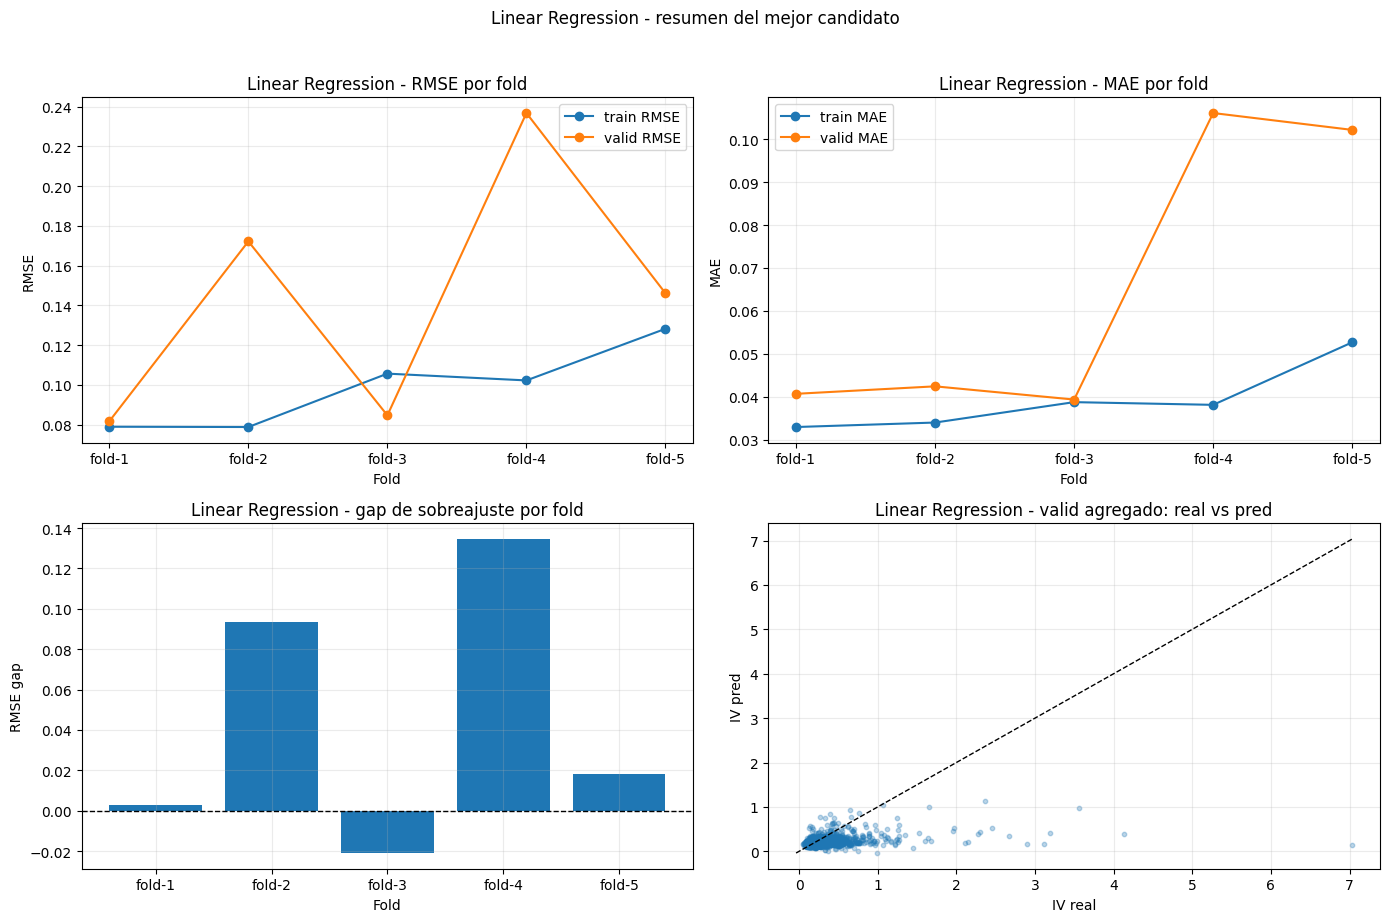

In [11]:
### Linear Regression ###
LINEAR_FIXED_PARAMS = {
    "fit_intercept": True,
    "copy_X": True,
    "n_jobs": None,
    "positive": False,
}

LINEAR_SEARCH_SPACE = {}

LINEAR_REGRESSION_CONFIG = {
    "family_name": "Linear Regression",
    "models": build_model_candidates(
        fixed_params=LINEAR_FIXED_PARAMS,
        search_space=LINEAR_SEARCH_SPACE,
        model_prefix="linear_regression",
        n_iter=1,
        seed=42,
    ),
}

total_family_models = len(LINEAR_REGRESSION_CONFIG["models"])
family_models_metrics_table = None
training_registry = {}
model_params_registry = {}

for model_i_name, model_i_params in tqdm(
    LINEAR_REGRESSION_CONFIG["models"].items(),
    total=total_family_models,
    desc=f"Entrenando familia: {LINEAR_REGRESSION_CONFIG['family_name']}",
):
    model_i_folds_metrics = []
    model_params_registry[model_i_name] = model_i_params

    for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
        linear_model = LinearRegression(**model_i_params)
        linear_model.fit(X_train_fold, y_train_fold)

        y_train_fold_pred = linear_model.predict(X_train_fold)
        y_valid_fold_pred = linear_model.predict(X_valid_fold)

        fold_metrics = calculate_regression_metrics_models(
            y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
        )
        model_i_folds_metrics.append((fold_name, fold_metrics))

        training_registry[f"{model_i_name}_{fold_name}"] = {
            "model": linear_model,
            "best_iteration": None,
            "best_score": np.nan,
            "metrics": fold_metrics,
            "y_valid_true": y_valid_fold.tolist(),
            "y_valid_pred": y_valid_fold_pred.tolist(),
        }

    metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
    family_models_metrics_table = add_model_metrics_row(
        metrics,
        model_name=model_i_name,
        metrics_table=family_models_metrics_table,
    )

print("\n" + "=" * 95)
print(f"Metricas de la familia de modelos: {LINEAR_REGRESSION_CONFIG['family_name']}")
display(family_models_metrics_table.head(15))
print("=" * 95)

best_model_linear = select_best_model_from_metrics_table(
    family_models_metrics_table,
    model_params_registry,
    training_registry,
    family_name=LINEAR_REGRESSION_CONFIG["family_name"],
    selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
)

linear_best_name = str(best_model_linear.index[0])
linear_best_params = model_params_registry[linear_best_name].copy()

Para este modelo lineal no se pueden tunear hiperparámetros, por lo que se tiene un único modelo a probar.

### Random Forest

Entrenando familia: Random Forest: 100%|██████████| 1/1 [01:36<00:00, 97.00s/it]

Entrenando familia: Random Forest: 100%|██████████| 1/1 [01:36<00:00, 97.00s/it]


Metricas de la familia de modelos: Random Forest


Entrenando familia: Random Forest: 100%|██████████| 1/1 [01:36<00:00, 97.00s/it]


Metricas de la familia de modelos: Random Forest


...

,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
rf_rs_001,0.164094,0.024507,0.004211,0.043065,0.011706,0.860556,0.031731,0.054501,0.030551,0.104632,0.053147,0.505892,0.180595


Mejor modelo según criterio: min('custom_error1') -> rf_rs_001


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
rf_rs_001,0.164094,0.024507,0.004211,0.043065,0.011706,0.860556,0.031731,0.054501,0.030551,0.104632,0.053147,0.505892,0.180595


{'criterion': 'squared_error', 'random_state': 42, 'n_jobs': -1, 'min_weight_fraction_leaf': 0.0, 'verbose': 0, 'bootstrap': True, 'n_estimators': 300, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_samples': 0.9, 'min_impurity_decrease': 0.0, 'ccp_alpha': 1e-05}


,fold,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,rmse_gap
0,fold-1,0.020161,0.034141,0.877319,0.030700,0.051456,0.626943,0.017315
1,fold-2,0.022352,0.036428,0.850432,0.029686,0.124555,0.495250,0.088127
2,fold-3,0.023701,0.039159,0.890524,0.028495,0.046874,0.737706,0.007715
3,fold-4,0.023816,0.039443,0.881513,0.095269,0.191494,0.468961,0.152051
4,fold-5,0.032507,0.066153,0.802993,0.088356,0.108781,0.200599,0.042628


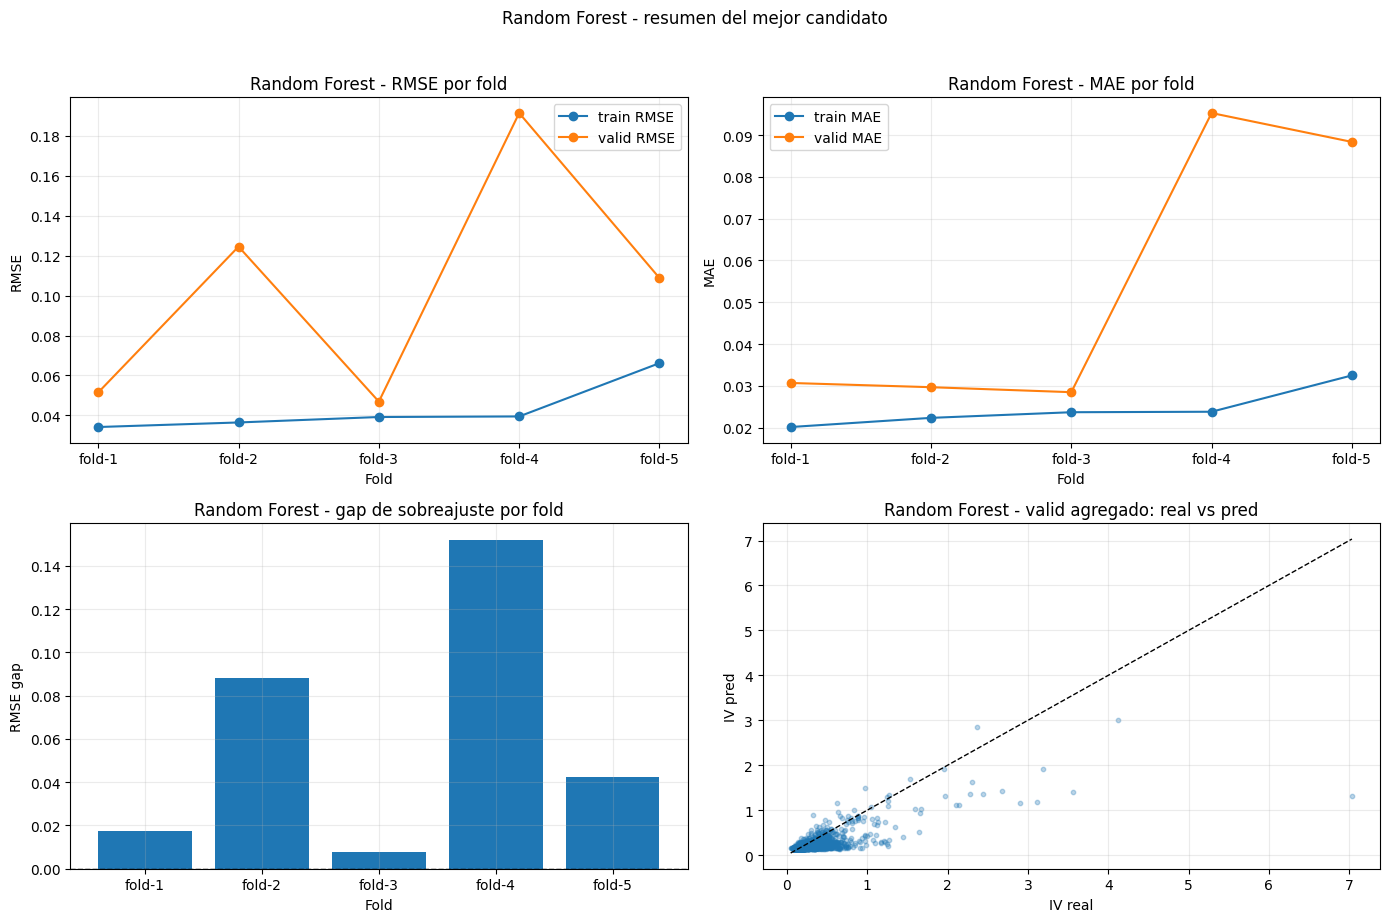

In [12]:
### Random Forest ###
RF_FIXED_PARAMS = {
    "criterion": "squared_error",
    "random_state": 42,
    "n_jobs": -1,
    "min_weight_fraction_leaf": 0.0,
    "verbose": 0,
    "bootstrap": True,
}

RF_SEARCH_SPACE = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 8, 12, 16, 24, 32],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [1.0, "sqrt", "log2", 0.7, 0.5],
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 0.9],
    "min_impurity_decrease": [0.0, 1e-6, 1e-5, 1e-4],
    "ccp_alpha": [0.0, 1e-6, 1e-5, 1e-4],
}

RANDOM_FOREST_CONFIG = {
    "family_name": "Random Forest",
    "models": build_model_candidates(
        fixed_params=RF_FIXED_PARAMS,
        search_space=RF_SEARCH_SPACE,
        model_prefix="rf_rs",
        n_iter=120,
        seed=42,
    ),
}

total_family_models = len(RANDOM_FOREST_CONFIG["models"])
family_models_metrics_table = None
training_registry = {}
model_params_registry = {}

for model_i_name, model_i_params in tqdm(
    RANDOM_FOREST_CONFIG["models"].items(),
    total=total_family_models,
    desc=f"Entrenando familia: {RANDOM_FOREST_CONFIG['family_name']}",
):
    model_i_folds_metrics = []
    model_params_registry[model_i_name] = model_i_params

    for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
        rf_model = RandomForestRegressor(**model_i_params)
        rf_model.fit(X_train_fold, y_train_fold)

        y_train_fold_pred = rf_model.predict(X_train_fold)
        y_valid_fold_pred = rf_model.predict(X_valid_fold)

        fold_metrics = calculate_regression_metrics_models(
            y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
        )
        model_i_folds_metrics.append((fold_name, fold_metrics))

        training_registry[f"{model_i_name}_{fold_name}"] = {
            "model": rf_model,
            "best_iteration": None,
            "best_score": np.nan,
            "metrics": fold_metrics,
            "y_valid_true": y_valid_fold.tolist(),
            "y_valid_pred": y_valid_fold_pred.tolist(),
        }

    metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
    family_models_metrics_table = add_model_metrics_row(
        metrics,
        model_name=model_i_name,
        metrics_table=family_models_metrics_table,
    )

print("\n" + "=" * 95)
print(f"Metricas de la familia de modelos: {RANDOM_FOREST_CONFIG['family_name']}")
display(family_models_metrics_table.head(15))
print("=" * 95)

best_model_rf = select_best_model_from_metrics_table(
    family_models_metrics_table,
    model_params_registry,
    training_registry,
    family_name=RANDOM_FOREST_CONFIG["family_name"],
    selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
)

rf_best_name = str(best_model_rf.index[0])
rf_best_params = model_params_registry[rf_best_name].copy()

### XGBoost

Entrenando familia: XGBoost: 100%|██████████| 1/1 [00:22<00:00, 22.31s/it]

Entrenando familia: XGBoost: 100%|██████████| 1/1 [00:22<00:00, 22.31s/it]


Metricas de la familia de modelos: XGBoost


Entrenando familia: XGBoost: 100%|██████████| 1/1 [00:22<00:00, 22.31s/it]


Metricas de la familia de modelos: XGBoost


...

,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
xgb_rs_001,0.156791,0.022325,0.004859,0.045449,0.01906,0.844719,0.076967,0.05648,0.036816,0.101229,0.054909,0.5177,0.305461


Mejor modelo según criterio: min('custom_error1') -> xgb_rs_001


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
xgb_rs_001,0.156791,0.022325,0.004859,0.045449,0.01906,0.844719,0.076967,0.05648,0.036816,0.101229,0.054909,0.5177,0.305461


{'booster': 'gbtree', 'objective': 'reg:pseudohubererror', 'eval_metric': 'rmse', 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'predictor': 'auto', 'enable_categorical': False, 'verbosity': 0, 'sampling_method': 'uniform', 'colsample_bylevel': 1.0, 'colsample_bynode': 1.0, 'max_delta_step': 0.0, 'grow_policy': 'depthwise', 'base_score': 0.2, 'n_estimators': 400, 'learning_rate': 0.08, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.8, 'colsample_bytree': 1.0, 'gamma': 0.0, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'max_bin': 128, 'num_parallel_tree': 2, 'early_stopping_rounds': 80}


,fold,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,rmse_gap
0,fold-1,0.016600,0.026106,0.928267,0.028070,0.042165,0.749500,0.016059
1,fold-2,0.021197,0.033175,0.875956,0.027893,0.113630,0.579909,0.080455
2,fold-3,0.020357,0.053176,0.798119,0.024086,0.039963,0.809348,-0.013213
3,fold-4,0.022194,0.035637,0.903274,0.093829,0.185647,0.500894,0.150010
4,fold-5,0.031275,0.079149,0.717978,0.108523,0.124739,-0.051150,0.045590


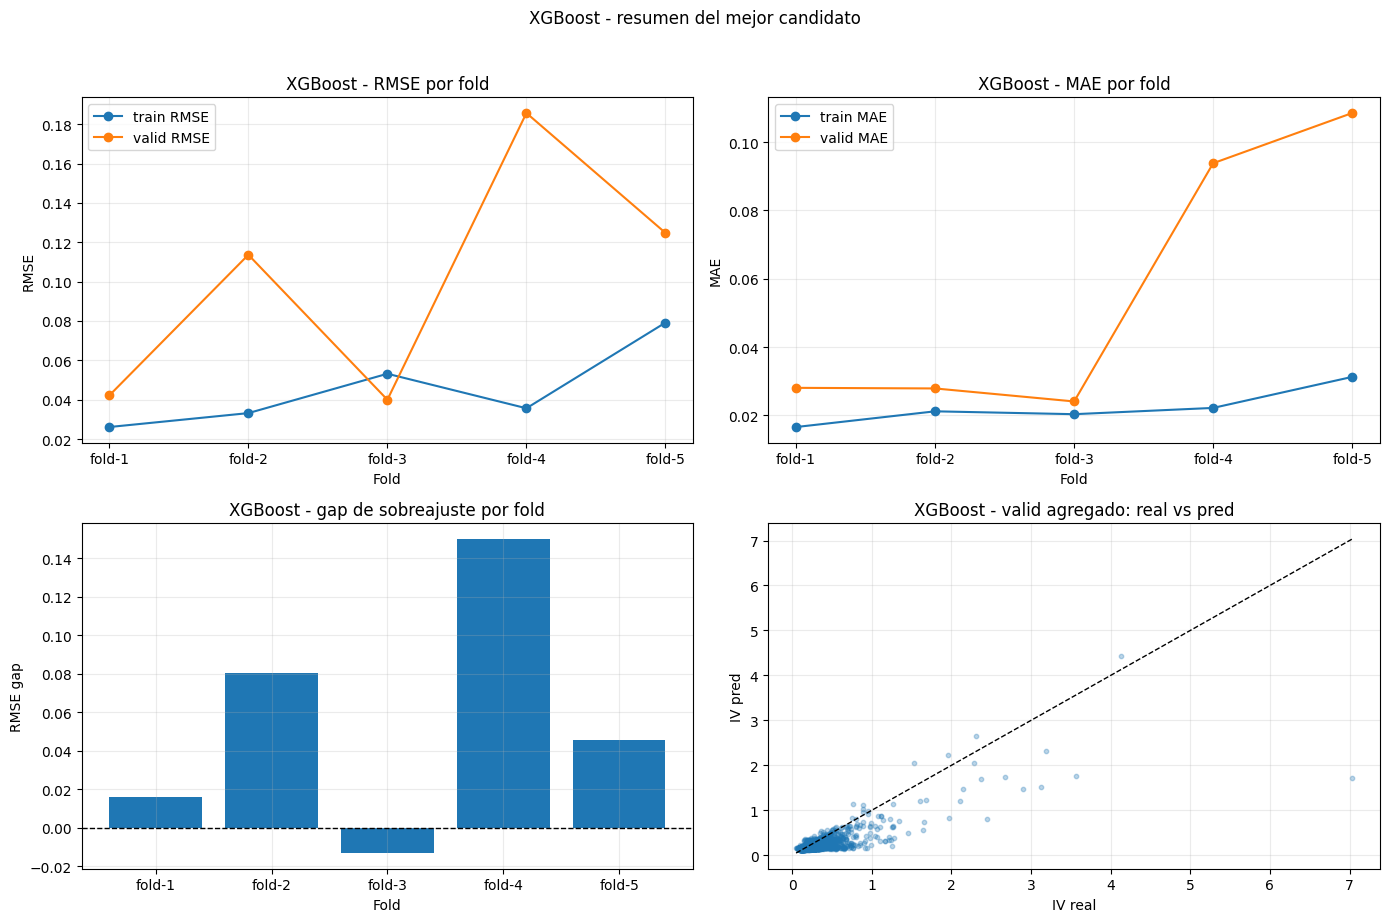

In [13]:
### XGBoost ###

XGB_FIXED_PARAMS = {
    "booster": "gbtree",
    "objective": "reg:pseudohubererror",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
    "predictor": "auto",
    "enable_categorical": False,
    "verbosity": 0,
    "sampling_method": "uniform",
    "colsample_bylevel": 1.0,
    "colsample_bynode": 1.0,
    "max_delta_step": 0.0,
    "grow_policy": "depthwise",
    "base_score": 0.20,  # Ajustado a la media del target para mejorar convergencia
}

XGB_SEARCH_SPACE = {
    "n_estimators": [400, 600, 800, 1000, 1400],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 8, 10, 15, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0.0, 0.01, 0.05, 0.1, 0.2, 0.5],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
    "max_bin": [128, 256, 512],
    "num_parallel_tree": [1, 2, 4],
    "early_stopping_rounds": [30, 50, 80],
}

XGBOOST_CONFIG = {
    "family_name": "XGBoost",
    "models": build_model_candidates(
        fixed_params=XGB_FIXED_PARAMS,
        search_space=XGB_SEARCH_SPACE,
        model_prefix="xgb_rs",
        n_iter=200,
        seed=42,
    ),
}

total_family_models = len(XGBOOST_CONFIG["models"])
family_models_metrics_table = None
training_registry = {}
model_params_registry = {}

for model_i_name, model_i_params in tqdm(
    XGBOOST_CONFIG["models"].items(),
    total=total_family_models,
    desc=f"Entrenando familia: {XGBOOST_CONFIG['family_name']}",
):
    model_i_folds_metrics = []
    model_params_registry[model_i_name] = model_i_params

    for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
        X_fit, y_fit, X_es, y_es = temporal_inner_split_for_early_stopping(
            X_train_fold, y_train_fold
        )

        xgb_model = XGBRegressor(**model_i_params)
        xgb_model.fit(
            X_fit,
            y_fit,
            eval_set=[(X_es, y_es)],
            verbose=False,
        )

        y_train_fold_pred = xgb_model.predict(X_train_fold)
        y_valid_fold_pred = xgb_model.predict(X_valid_fold)

        fold_metrics = calculate_regression_metrics_models(
            y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
        )
        model_i_folds_metrics.append((fold_name, fold_metrics))

        training_registry[f"{model_i_name}_{fold_name}"] = {
            "model": xgb_model,
            "best_iteration": int(getattr(xgb_model, "best_iteration", -1)),
            "best_score": float(getattr(xgb_model, "best_score", np.nan)),
            "metrics": fold_metrics,
            "y_valid_true": y_valid_fold.tolist(),
            "y_valid_pred": y_valid_fold_pred.tolist(),
        }

    metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
    family_models_metrics_table = add_model_metrics_row(
        metrics,
        model_name=model_i_name,
        metrics_table=family_models_metrics_table,
    )

print("\n" + "=" * 95)
print(f"Metricas de la familia de modelos: {XGBOOST_CONFIG['family_name']}")
display(family_models_metrics_table.head(15))
print("=" * 95)

best_model_xgb = select_best_model_from_metrics_table(
    family_models_metrics_table,
    model_params_registry,
    training_registry,
    family_name=XGBOOST_CONFIG["family_name"],
    selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
)

xgb_best_name = str(best_model_xgb.index[0])
xgb_best_params = model_params_registry[xgb_best_name].copy()

### Redes Neuronales Secuenciales

Entrenando familia: Sequential NN: 100%|██████████| 1/1 [01:57<00:00, 117.15s/it]

Entrenando familia: Sequential NN: 100%|██████████| 1/1 [01:57<00:00, 117.15s/it]


Metricas de la familia de modelos: Sequential NN


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
nn_seq_rs_001,0.182951,0.034248,0.004904,0.091629,0.01833,0.365862,0.0744,0.064811,0.034702,0.136468,0.051414,0.069311,0.315381


Mejor modelo según criterio: min('custom_error1') -> nn_seq_rs_001


...

,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
nn_seq_rs_001,0.182951,0.034248,0.004904,0.091629,0.01833,0.365862,0.0744,0.064811,0.034702,0.136468,0.051414,0.069311,0.315381


Mejor modelo según criterio: min('custom_error1') -> nn_seq_rs_001


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
nn_seq_rs_001,0.182951,0.034248,0.004904,0.091629,0.01833,0.365862,0.0744,0.064811,0.034702,0.136468,0.051414,0.069311,0.315381


{'patience': 12, 'epochs': 150, 'verbose': 0, 'hidden_layers': [64], 'dropout_rate': 0.2, 'l2_reg': 0.0005, 'learning_rate': 0.0005, 'batch_size': 512, 'activation': 'gelu', 'kernel_initializer': 'he_normal', 'use_batch_norm': False, 'use_lr_scheduler': True, 'loss': 'huber'}


,fold,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,rmse_gap
0,fold-1,0.028152,0.070847,0.471700,0.036784,0.076787,0.169250,0.005940
1,fold-2,0.030822,0.072337,0.410230,0.037970,0.162807,0.137608,0.090470
2,fold-3,0.038581,0.102557,0.249091,0.036486,0.080320,0.229858,-0.022237
3,fold-4,0.032423,0.093325,0.336658,0.095180,0.211253,0.353721,0.117928
4,fold-5,0.041264,0.119081,0.361631,0.117637,0.151174,-0.543884,0.032093


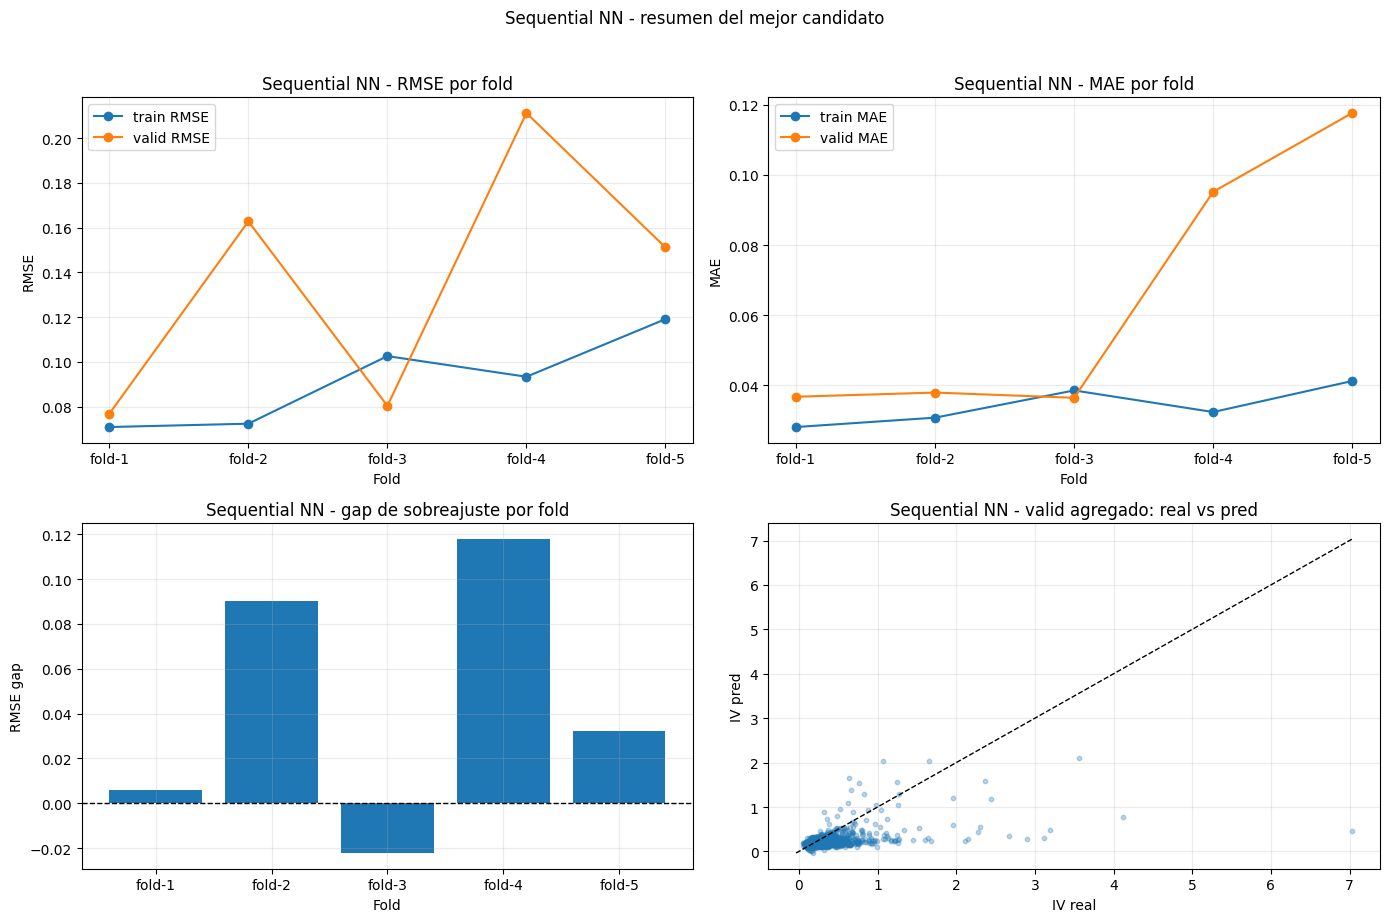

Entrenando familia: Sequential NN: 100%|██████████| 1/1 [01:57<00:00, 117.15s/it]


Metricas de la familia de modelos: Sequential NN


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
nn_seq_rs_001,0.182951,0.034248,0.004904,0.091629,0.01833,0.365862,0.0744,0.064811,0.034702,0.136468,0.051414,0.069311,0.315381


Mejor modelo según criterio: min('custom_error1') -> nn_seq_rs_001


,custom_error1,train_mae,train_mae_std,train_rmse,train_rmse_std,train_r2,train_r2_std,valid_mae,valid_mae_std,valid_rmse,valid_rmse_std,valid_r2,valid_r2_std
model,,,,,,,,,,,,,
nn_seq_rs_001,0.182951,0.034248,0.004904,0.091629,0.01833,0.365862,0.0744,0.064811,0.034702,0.136468,0.051414,0.069311,0.315381


{'patience': 12, 'epochs': 150, 'verbose': 0, 'hidden_layers': [64], 'dropout_rate': 0.2, 'l2_reg': 0.0005, 'learning_rate': 0.0005, 'batch_size': 512, 'activation': 'gelu', 'kernel_initializer': 'he_normal', 'use_batch_norm': False, 'use_lr_scheduler': True, 'loss': 'huber'}


,fold,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,rmse_gap
0,fold-1,0.028152,0.070847,0.471700,0.036784,0.076787,0.169250,0.005940
1,fold-2,0.030822,0.072337,0.410230,0.037970,0.162807,0.137608,0.090470
2,fold-3,0.038581,0.102557,0.249091,0.036486,0.080320,0.229858,-0.022237
3,fold-4,0.032423,0.093325,0.336658,0.095180,0.211253,0.353721,0.117928
4,fold-5,0.041264,0.119081,0.361631,0.117637,0.151174,-0.543884,0.032093


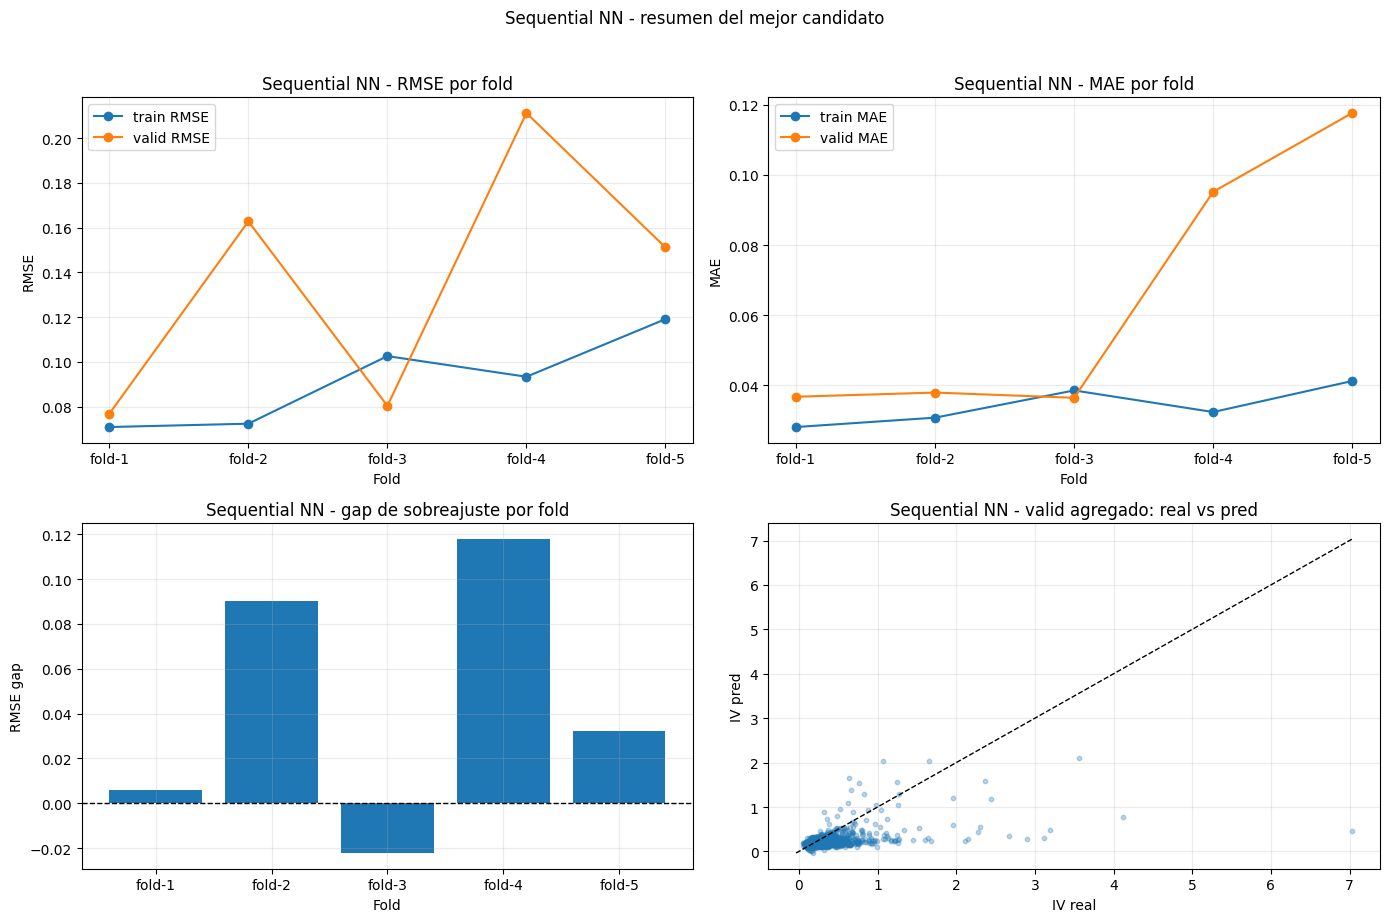

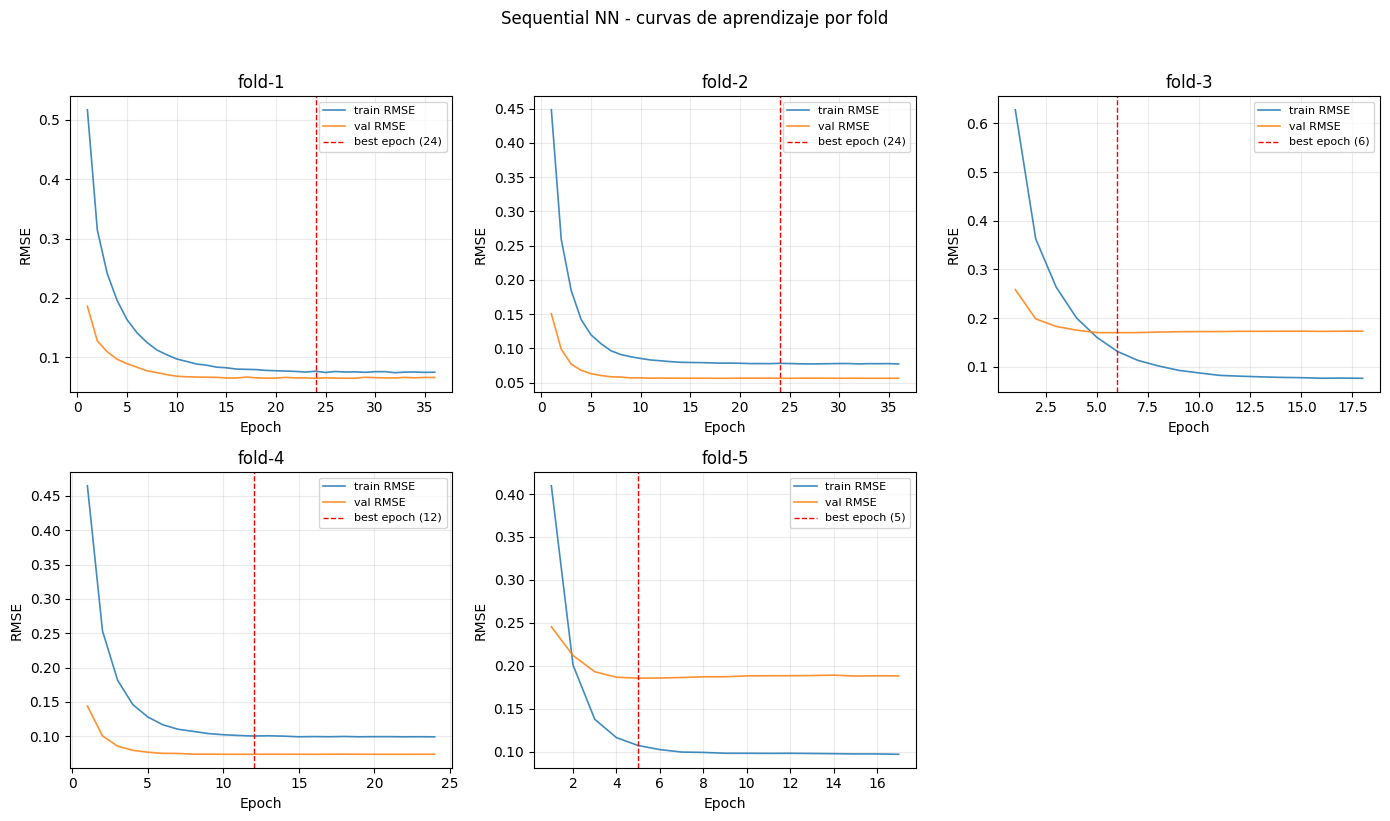

In [16]:
### Redes Neuronales Secuenciales (MLP) ###

def scale_only_numeric_features(
    X_fit_raw,
    X_es_raw,
    X_train_full_raw,
    X_valid_raw,
    numeric_col_indices,
):
    """
    Escala solo las columnas identificadas por numeric_col_indices y deja intactas las categóricas.
    El scaler se ajusta únicamente sobre X_fit_raw para evitar cualquier data leakage.
    """
    scaler = StandardScaler()
    idx = list(numeric_col_indices)

    X_fit_scaled = X_fit_raw.copy()
    X_fit_scaled[:, idx] = scaler.fit_transform(X_fit_raw[:, idx])

    X_es_scaled = X_es_raw.copy()
    X_es_scaled[:, idx] = scaler.transform(X_es_raw[:, idx])
    
    X_train_full_scaled = X_train_full_raw.copy()
    X_train_full_scaled[:, idx] = scaler.transform(X_train_full_raw[:, idx])

    X_valid_scaled = X_valid_raw.copy()
    X_valid_scaled[:, idx] = scaler.transform(X_valid_raw[:, idx])

    return X_fit_scaled, X_es_scaled, X_train_full_scaled, X_valid_scaled


def build_sequential_nn_model(params: dict, input_dim: int):
    """Construye una MLP secuencial a partir del dict de hiperparámetros."""
    tf.random.set_seed(42)

    hidden_layers = params["hidden_layers"]
    l2_reg = params["l2_reg"]
    learning_rate = params["learning_rate"]
    activation = params["activation"]
    dropout_rate = params["dropout_rate"]
    use_batch_norm = params["use_batch_norm"]
    kernel_initializer = params["kernel_initializer"]
    loss = params["loss"]

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(layers.Dense(
            units,
            activation=None,
            kernel_initializer=kernel_initializer,
            kernel_regularizer=regularizers.l2(l2_reg),
        ))

        if use_batch_norm:
            model.add(layers.BatchNormalization())

        model.add(layers.Activation(activation))

        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="linear"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )

    return model


def plot_nn_learning_curves(training_registry, best_model_row, family_name=None):
    """
    Muestra las curvas de aprendizaje (train RMSE vs val RMSE por epoch) del mejor modelo
    en cada fold, con una línea vertical en el early-stopping point.
    """
    best_model_name = str(best_model_row.index[0])
    plot_title = family_name

    fold_keys = sorted(
        [k for k in training_registry.keys() if k.startswith(f"{best_model_name}_fold-")],
        key=lambda x: int(x.split("fold-")[-1]),
    )

    n_folds = len(fold_keys)
    n_cols = 3
    n_rows = int(np.ceil(n_folds / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax_idx, fold_key in enumerate(fold_keys):
        ax = axes_flat[ax_idx]
        record = training_registry[fold_key]
        fold_name = fold_key.split("_")[-1]
        epoch_history = record.get("epoch_history", {})

        val_rmse = epoch_history.get("val_rmse", [])
        train_rmse = epoch_history.get("rmse", [])
        best_epoch = record.get("best_iteration", None)

        epochs = range(1, len(val_rmse) + 1)

        if train_rmse:
            ax.plot(epochs, train_rmse, label="train RMSE", linewidth=1.2, alpha=0.85)
        ax.plot(epochs, val_rmse, label="val RMSE", linewidth=1.2, alpha=0.85)

        if best_epoch and best_epoch <= len(val_rmse):
            ax.axvline(
                best_epoch, color="red", linestyle="--", linewidth=1,
                label=f"best epoch ({best_epoch})"
            )

        ax.set_title(fold_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("RMSE")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    for ax_idx in range(n_folds, len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    fig.suptitle(f"{plot_title} - curvas de aprendizaje por fold", y=1.02)
    plt.tight_layout()
    plt.show()


NN_FIXED_PARAMS = {
    "patience": 12,
    "epochs": 150,
    "verbose": 0,
}

NN_SEARCH_SPACE = {
    "hidden_layers": [
        [32],
        [64],
        [128],
        [256],
        [512],
        [32, 32],
        [64, 32],
        [64, 64],
        [128, 64],
        [128, 128],
        [256, 128],
        [256, 256],
        [128, 64, 32],
        [128, 128, 64],
        [128, 128, 128],
        [256, 128, 64],
        [256, 256, 128],
        [256, 128, 64, 32],
        [256, 256, 128, 64],
        [512, 256, 128, 64],
    ],
    "dropout_rate": [0.0, 0.05, 0.1, 0.2, 0.3],
    "l2_reg": [0.0, 1e-5, 1e-4, 5e-4, 1e-3],
    "learning_rate": [5e-5, 1e-4, 5e-4, 1e-3, 3e-3],
    "batch_size": [128, 256, 512, 1024, 2048],
    "activation": ["relu", "gelu"],
    "kernel_initializer": ["he_normal", "he_uniform"],
    "use_batch_norm": [True, False],
    "use_lr_scheduler": [True, False],
    "loss": ["huber", "mse"],
}

NN_SEQ_CONFIG = {
    "family_name": "Sequential NN",
    "models": build_model_candidates(
        fixed_params=NN_FIXED_PARAMS,
        search_space=NN_SEARCH_SPACE,
        model_prefix="nn_seq_rs",
        n_iter=75,
        seed=42,
    ),
}

# Índices de columnas numéricas calculados por nombre desde BASE_FEATURE_COLS
NUMERIC_COL_INDICES = [BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS]

total_family_models = len(NN_SEQ_CONFIG["models"])
family_models_metrics_table = None
training_registry = {}
model_params_registry = {}

for model_i_name, model_i_params in tqdm(
    NN_SEQ_CONFIG["models"].items(),
    total=total_family_models,
    desc=f"Entrenando familia: {NN_SEQ_CONFIG['family_name']}",
):
    model_i_folds_metrics = []
    model_params_registry[model_i_name] = model_i_params

    for fold_name, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold in fold_data_cache:
        X_fit_raw, y_fit, X_es_raw, y_es = temporal_inner_split_for_early_stopping(
            X_train_fold, y_train_fold
        )

        X_fit_scaled, X_es_scaled, X_train_full_scaled, X_valid_scaled = scale_only_numeric_features(
            X_fit_raw, X_es_raw, X_train_fold, X_valid_fold, NUMERIC_COL_INDICES
        )

        keras.backend.clear_session()
        nn_model = build_sequential_nn_model(model_i_params, input_dim=X_fit_scaled.shape[1])

        early_stop = EarlyStopping(
            monitor="val_rmse",
            mode="min",
            patience=model_i_params["patience"],
            restore_best_weights=True,
            verbose=0,
        )

        callbacks = [early_stop]

        if model_i_params.get("use_lr_scheduler", False):
            callbacks.append(
                ReduceLROnPlateau(
                    monitor="val_rmse",
                    factor=0.5,
                    patience=5,
                    min_lr=1e-6,
                    verbose=0,
                )
            )

        history = nn_model.fit(
            X_fit_scaled,
            y_fit,
            epochs=model_i_params["epochs"],
            batch_size=model_i_params["batch_size"],
            validation_data=(X_es_scaled, y_es),
            callbacks=callbacks,
            verbose=model_i_params["verbose"],
        )

        best_epoch = int(np.argmin(history.history["val_rmse"])) + 1
        best_val_rmse = float(np.min(history.history["val_rmse"]))

        y_train_fold_pred = nn_model.predict(X_train_full_scaled, verbose=0).flatten()
        y_valid_fold_pred = nn_model.predict(X_valid_scaled, verbose=0).flatten()

        fold_metrics = calculate_regression_metrics_models(
            y_train_fold, y_train_fold_pred, y_valid_fold, y_valid_fold_pred
        )
        model_i_folds_metrics.append((fold_name, fold_metrics))

        training_registry[f"{model_i_name}_{fold_name}"] = {
            "model": nn_model,
            "best_iteration": best_epoch,
            "best_score": best_val_rmse,
            "epoch_history": {
                "rmse": [float(v) for v in history.history.get("rmse", [])],
                "val_rmse": [float(v) for v in history.history.get("val_rmse", [])],
            },
            "metrics": fold_metrics,
            "y_valid_true": y_valid_fold.tolist(),
            "y_valid_pred": y_valid_fold_pred.tolist(),
        }

    metrics = calculate_metrics_across_folds([m for _, m in model_i_folds_metrics])
    family_models_metrics_table = add_model_metrics_row(
        metrics,
        model_name=model_i_name,
        metrics_table=family_models_metrics_table,
    )

print("\n" + "=" * 95)
print(f"Metricas de la familia de modelos: {NN_SEQ_CONFIG['family_name']}")
display(family_models_metrics_table.head(15))
print("=" * 95)

best_model_nn_seq = select_best_model_from_metrics_table(
    family_models_metrics_table,
    model_params_registry,
    training_registry,
    family_name=NN_SEQ_CONFIG["family_name"],
    selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_1,
)

plot_nn_learning_curves(
    training_registry,
    best_model_nn_seq,
    family_name=NN_SEQ_CONFIG["family_name"],
)

nn_seq_best_name = str(best_model_nn_seq.index[0])
nn_seq_best_params = model_params_registry[nn_seq_best_name].copy()

Ahora, con todas las familias entrenadas, vamos a reentrenar el mejor modelo de cada una de ellas, considerando los mejores parámetros de cada familia, generando un nuevo modelo que entrene en train y revisemos en validación.

Reentrenando modelo Linear Regression con mejores hiperparámetros y evaluando en valid...
Reentrenando modelo Random Forest con mejores hiperparámetros y evaluando en valid...
Reentrenando modelo XGBoost con mejores hiperparámetros y evaluando en valid...
Reentrenando modelo Sequential NN con mejores hiperparámetros y evaluando en valid...
COMPARATIVA DE MEJORES MODELOS REENTRENADOS (TRAIN -> VALID)


,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,custom_error2
linear_best,0.058460,0.129057,0.261864,0.051570,0.427339,-10.243607,0.699284
rf_best,0.038713,0.070400,0.780354,0.038159,0.076920,0.635722,0.122834
xgb_best,0.038059,0.071573,0.772973,0.043025,0.067755,0.717355,0.106953
nn_seq_best,0.051158,0.114331,0.420699,0.042169,0.103481,0.340698,0.149219


Mejor modelo según criterio: min('custom_error2') -> xgb_best


,train_mae,train_rmse,train_r2,valid_mae,valid_rmse,valid_r2,custom_error2
xgb_best,0.038059,0.071573,0.772973,0.043025,0.067755,0.717355,0.106953


{'booster': 'gbtree', 'objective': 'reg:pseudohubererror', 'eval_metric': 'rmse', 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'predictor': 'auto', 'enable_categorical': False, 'verbosity': 0, 'sampling_method': 'uniform', 'colsample_bylevel': 1.0, 'colsample_bynode': 1.0, 'max_delta_step': 0.0, 'grow_policy': 'depthwise', 'base_score': 0.2, 'n_estimators': 400, 'learning_rate': 0.08, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.8, 'colsample_bytree': 1.0, 'gamma': 0.0, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'max_bin': 128, 'num_parallel_tree': 2, 'early_stopping_rounds': 80}


""


KeyError: 'fold'

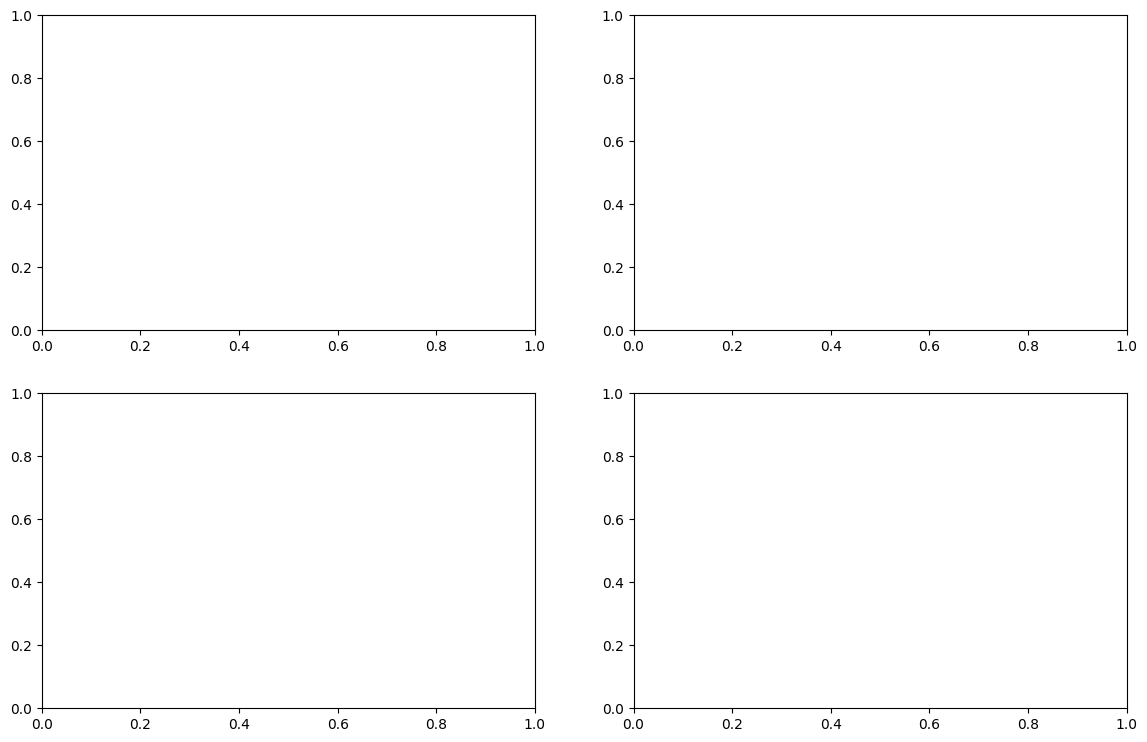

In [ ]:
# Elección del mejor modelo global entre los mejores de cada familia

# Configuración de selección del mejor modelo
MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2 = {
    "metric": "custom_error2",
    "mode": "min",
    "delta": 0.25,
    "beta": 0.75,
    "base_metric": "rmse",
}

# Diccionario de custom_error1 del mejor modelo de cada familia
linear_best_model_name = "linear_best"
xgb_best_model_name = "xgb_best"
rf_best_model_name = "rf_best"
nn_seq_best_model_name = "nn_seq_best"

custom_error1_by_family = {
    linear_best_model_name: float(best_model_linear["custom_error1"].iloc[0]),
    rf_best_model_name: float(best_model_rf["custom_error1"].iloc[0]),
    xgb_best_model_name: float(best_model_xgb["custom_error1"].iloc[0]),
    nn_seq_best_model_name: float(best_model_nn_seq["custom_error1"].iloc[0]),
}

# Tabla de métricas para esta segunda fase
metric_table_family_best = pd.DataFrame()

def add_custom_error2(
    metrics_table: pd.DataFrame,
    custom_error1_by_family: dict,
    round_digits: int = 6,
):
    """
    Calcula el custom_error2 para cada modelo en metrics_table usando la fórmula:
           custom_error2 = valid_rmse + delta * custom_error1_from_family + beta * overfit_gap
    """

    base_metric = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["base_metric"]
    delta = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["delta"]
    beta = MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["beta"]

    train_metric_col = f"train_{base_metric}"
    valid_metric_col = f"valid_{base_metric}"

    train_metric = pd.to_numeric(metrics_table[train_metric_col])
    valid_metric = pd.to_numeric(metrics_table[valid_metric_col])
    custom_error1_from_family = pd.to_numeric(
        metrics_table.index.to_series().map(custom_error1_by_family)
    )

    overfit_gap = np.maximum(0.0, valid_metric - train_metric)

    metrics_table = metrics_table.copy()
    metrics_table[MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["metric"]] = np.round(
        valid_metric + delta * custom_error1_from_family + beta * overfit_gap,
        round_digits,
    )

    metrics_table.sort_values(by=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2["metric"], inplace=True)

    return metrics_table

# Carpeta para guardar los mejores modelos reentrenados
best_models_dir = Path("artifacts") / "best_model_per_family"
best_models_dir.mkdir(parents=True, exist_ok=True)

# Dataset final para reentrenar y evaluar
X_train_full_raw = train_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
y_train_full = train_df[TARGET_COL].to_numpy(dtype=float)
X_valid_full_raw = valid_df[BASE_FEATURE_COLS].to_numpy(dtype=float)
y_valid_full = valid_df[TARGET_COL].to_numpy(dtype=float)

retrained_metrics_table = None
retrained_training_registry = {}
retrained_params_registry = {}

# ===============================
# Linear Regression (reentrenado)
# ===============================
print(f"Reentrenando modelo Linear Regression con mejores hiperparámetros y evaluando en valid...")
linear_retrained_model = LinearRegression(**linear_best_params)
linear_retrained_model.fit(X_train_full_raw, y_train_full)

linear_train_pred = linear_retrained_model.predict(X_train_full_raw)
linear_valid_pred = linear_retrained_model.predict(X_valid_full_raw)

linear_metrics = calculate_regression_metrics_models(
    y_train_full, linear_train_pred, y_valid_full, linear_valid_pred
)
metric_table_family_best[linear_best_model_name] = linear_metrics

retrained_training_registry[linear_best_model_name] = {
    "metrics": linear_metrics,
    "y_valid_true": y_valid_full.tolist(),
    "y_valid_pred": linear_valid_pred.tolist(),
}
retrained_params_registry[linear_best_model_name] = linear_best_params.copy()

linear_model_artifact_path = best_models_dir / f"{linear_best_model_name}.joblib"
joblib.dump(linear_retrained_model, linear_model_artifact_path)

# =========================
# Random Forest (reentrenado)
# =========================
print(f"Reentrenando modelo Random Forest con mejores hiperparámetros y evaluando en valid...")
rf_retrained_model = RandomForestRegressor(**rf_best_params)
rf_retrained_model.fit(X_train_full_raw, y_train_full)

rf_train_pred = rf_retrained_model.predict(X_train_full_raw)
rf_valid_pred = rf_retrained_model.predict(X_valid_full_raw)

rf_metrics = calculate_regression_metrics_models(
    y_train_full, rf_train_pred, y_valid_full, rf_valid_pred
)
metric_table_family_best[rf_best_model_name] = rf_metrics

retrained_training_registry[rf_best_model_name] = {
    "metrics": rf_metrics,
    "y_valid_true": y_valid_full.tolist(),
    "y_valid_pred": rf_valid_pred.tolist(),
}
retrained_params_registry[rf_best_model_name] = rf_best_params.copy()

rf_model_artifact_path = best_models_dir / f"{rf_best_model_name}.joblib"
joblib.dump(rf_retrained_model, rf_model_artifact_path)

# ====================
# XGBoost (reentrenado)
# ====================
print(f"Reentrenando modelo XGBoost con mejores hiperparámetros y evaluando en valid...")
xgb_retrained_model = XGBRegressor(**xgb_best_params)
xgb_retrained_model.fit(
    X_train_full_raw,
    y_train_full,
    eval_set=[(X_valid_full_raw, y_valid_full)],
    verbose=False,
)

xgb_train_pred = xgb_retrained_model.predict(X_train_full_raw)
xgb_valid_pred = xgb_retrained_model.predict(X_valid_full_raw)

xgb_metrics = calculate_regression_metrics_models(
    y_train_full, xgb_train_pred, y_valid_full, xgb_valid_pred
)
metric_table_family_best[xgb_best_model_name] = xgb_metrics

retrained_training_registry[xgb_best_model_name] = {
    "metrics": xgb_metrics,
    "y_valid_true": y_valid_full.tolist(),
    "y_valid_pred": xgb_valid_pred.tolist(),
}
retrained_params_registry[xgb_best_model_name] = xgb_best_params.copy()

xgb_model_artifact_path = best_models_dir / f"{xgb_best_model_name}.joblib"
joblib.dump(xgb_retrained_model, xgb_model_artifact_path)

# =========================
# Sequential NN (reentrenado)
# =========================
print(f"Reentrenando modelo Sequential NN con mejores hiperparámetros y evaluando en valid...")
X_train_nn_scaled, X_valid_nn_scaled,_,_ = scale_only_numeric_features(
    X_train_full_raw,
    X_valid_full_raw,
    X_train_full_raw,
    X_valid_full_raw,
    NUMERIC_COL_INDICES,
)

keras.backend.clear_session()
nn_retrained_model = build_sequential_nn_model(
    nn_seq_best_params,
    input_dim=X_train_nn_scaled.shape[1],
)

nn_callbacks = [
    EarlyStopping(
        monitor="val_rmse",
        mode="min",
        patience=nn_seq_best_params["patience"],
        restore_best_weights=True,
        verbose=0,
    )
]
if nn_seq_best_params.get("use_lr_scheduler", False):
    nn_callbacks.append(
        ReduceLROnPlateau(
            monitor="val_rmse",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0,
        )
    )

nn_history = nn_retrained_model.fit(
    X_train_nn_scaled,
    y_train_full,
    epochs=nn_seq_best_params["epochs"],
    batch_size=nn_seq_best_params["batch_size"],
    validation_data=(X_valid_nn_scaled, y_valid_full),
    callbacks=nn_callbacks,
    verbose=nn_seq_best_params["verbose"],
)

nn_train_pred = nn_retrained_model.predict(X_train_nn_scaled, verbose=0).flatten()
nn_valid_pred = nn_retrained_model.predict(X_valid_nn_scaled, verbose=0).flatten()

nn_metrics = calculate_regression_metrics_models(
    y_train_full, nn_train_pred, y_valid_full, nn_valid_pred
)

nn_best_epoch = int(np.argmin(nn_history.history["val_rmse"])) + 1
nn_best_val_rmse = float(np.min(nn_history.history["val_rmse"]))

metric_table_family_best[nn_seq_best_model_name] = nn_metrics

retrained_training_registry[nn_seq_best_model_name] = {
    "best_iteration": nn_best_epoch,
    "best_score": nn_best_val_rmse,
    "epoch_history": {
        "rmse": [float(v) for v in nn_history.history.get("rmse", [])],
        "val_rmse": [float(v) for v in nn_history.history.get("val_rmse", [])],
    },
    "metrics": nn_metrics,
    "y_valid_true": y_valid_full.tolist(),
    "y_valid_pred": nn_valid_pred.tolist(),
}
retrained_params_registry[nn_seq_best_model_name] = nn_seq_best_params.copy()

nn_model_artifact_path = best_models_dir / f"{nn_seq_best_model_name}.keras"
nn_retrained_model.save(nn_model_artifact_path)

print("=" * 100)
print("COMPARATIVA DE MEJORES MODELOS REENTRENADOS (TRAIN -> VALID)")
print("=" * 100)

# Aplicar el cálulo del custom_error2 a la tabla de métricas de los modelos reentrenados
metric_table_family_best = add_custom_error2(
    metric_table_family_best.T,
    custom_error1_by_family,
)
display(metric_table_family_best)

# Seleccionar el mejor modelo global entre los mejores de cada familia usando custom_error2
best_model_global = select_best_model_from_metrics_table(
    metric_table_family_best,
    retrained_params_registry,
    retrained_training_registry,
    family_name="Comparativa final de mejores familias reentrenadas",
    selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2,
)

# # Graficas
# for family_key, family_name in [
#     (linear_best_model_name, "Linear Regression"),
#     (rf_best_model_name, "Random Forest"),
#     (xgb_best_model_name, "XGBoost"),
#     (nn_seq_best_model_name, "Sequential NN"),
# ]:
#     single_model_row = pd.DataFrame(index=[family_key])
#     best_model_family_graphics(
#         retrained_training_registry,
#         single_model_row,
#         family_name=f"{family_name} (reentrenado train->valid)",
#     )

# # Curvas de entrenamiento para la red neuronal reentrenada
# nn_retrained_row = pd.DataFrame(index=[nn_seq_best_model_name])
# plot_nn_learning_curves(
#     retrained_training_registry,
#     nn_retrained_row,
#     family_name="Sequential NN (reentrenado train->valid)",
# )

# best_model_retrained_global = select_best_model_from_metrics_table(
#     retrained_metrics_table,
#     retrained_params_registry,
#     retrained_training_registry,
#     family_name="Comparativa final de mejores familias reentrenadas",
#     selection_config=MODEL_SELECTION_CONFIG_CUSTOM_ERROR_2,
# )
